# Correlation-Based Feature Selection

Correlation-Based Feature Selection is a filter method used to select
features based on their relationship with the target and their
relationship with other features.

The main goals are:

- Select features that are strongly related to the target.
- Remove features that are weakly related to the target.
- Remove redundant features that are highly correlated with each other.

## What is Correlation?

Correlation measures the strength and direction of a linear relationship
between two numerical variables.

The correlation coefficient ranges from:

- +1 → Perfect positive correlation
- 0 → No linear correlation
- -1 → Perfect negative correlation

Examples:

+0.90 → Strong positive relationship

-0.85 → Strong negative relationship

+0.05 → Very weak relationship

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

df = pd.DataFrame({
    "Age": np.random.randint(18, 60, 200),
    "Income": np.random.randint(20000, 100000, 200),
    "Experience": np.random.randint(0, 20, 200),
    "Target": np.random.randint(0, 2, 200)
})

df.head()

,Age,Income,Experience,Target
0,56,45342,6,1
1,46,57157,4,1
2,32,87863,2,1
3,25,72083,11,1
4,38,85733,15,1


In [2]:
correlation_matrix = df.corr()

correlation_matrix

,Age,Income,Experience,Target
Age,1.000000,0.032561,-0.066043,-0.122454
Income,0.032561,1.000000,-0.044615,0.031615
Experience,-0.066043,-0.044615,1.000000,-0.032960
Target,-0.122454,0.031615,-0.032960,1.000000


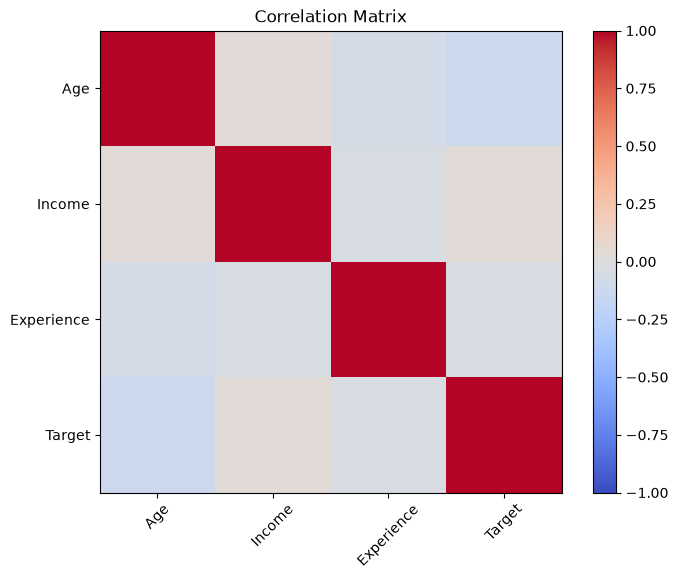

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

## Correlation with Target

For feature selection, we are often interested in the correlation between
each feature and the target.

A feature with a correlation close to +1 or -1 has a strong linear
relationship with the target.

A feature with a correlation close to 0 has a weak linear relationship
with the target.

In [4]:
target_correlation = (
    df.corr()["Target"]
    .drop("Target")
    .sort_values(
        key=abs,
        ascending=False
    )
)

target_correlation

Age          -0.122454
Experience   -0.032960
Income        0.031615
Name: Target, dtype: float64

## Selecting Features Using Correlation

We can define a correlation threshold.

For example:

|Correlation with Target| >= 0.20

Features with an absolute correlation below this threshold can be
considered weakly correlated with the target.

The threshold should be chosen according to the dataset and problem.

In [5]:
threshold = 0.20

selected_features = target_correlation[
    abs(target_correlation) >= threshold
].index

selected_features

Index([], dtype='str')

## Removing Redundant Features

Correlation can also be used to identify features that are highly
correlated with each other.

For example:

Income
Annual_Income

may contain almost the same information.

Keeping both features may introduce redundancy.

A common threshold is:

|Correlation| > 0.90

When two features are highly correlated, we can consider removing one.

In [6]:
X = df.drop(columns="Target")

corr_matrix = X.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

highly_correlated = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]

highly_correlated

[]

In [7]:
X_reduced = X.drop(
    columns=highly_correlated
)

X_reduced.head()

,Age,Income,Experience
0,56,45342,6
1,46,57157,4
2,32,87863,2
3,25,72083,11
4,38,85733,15


In [8]:
X = df.drop(columns="Target")
y = df["Target"]

# Correlation with target
target_corr = X.corrwith(y).abs()

# Select features based on target correlation
selected = target_corr[
    target_corr >= 0.20
].index

X_selected = X[selected]

X_selected.head()

""
0
1
2
3
4


## Choosing a Correlation Threshold

There is no single perfect correlation threshold.

Common examples include:

0.10 → Weak relationship

0.20 → Moderate screening threshold

0.50 → Strong relationship

0.70 → Very strong relationship

0.90 → Often used to identify redundant features

The correct threshold depends on:

- Dataset
- Problem
- Domain knowledge
- Model